# Titanic Survival Predictor

Binary classification task: predict whether a passenger survived the Titanic disaster based on demographic and ticket attributes.

**Dataset:** [Kaggle Titanic Competition](https://www.kaggle.com/c/titanic) — `train.csv` (891 passengers, 12 columns)  
**Target:** `Survived` — 1 = survived, 0 = did not survive  
**Approach:** Compare four scikit-learn classifiers using a shared preprocessing pipeline, evaluated on F1 and ROC-AUC.

## 1. Imports & Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.impute          import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.metrics         import f1_score, roc_auc_score, classification_report

## 2. Data Loading

Load the dataset and perform a quick sanity check on shape, data types, and missing values.

In [ ]:
# Data: https://www.kaggle.com/c/titanic/data
df = pd.read_csv('data/train.csv')

print(f'Shape: {df.shape}')
print()
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print(df.describe().round(2))

(891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49

## 3. Exploratory Data Analysis

`Sex` and `Pclass` are the two strongest raw predictors — visualizing survival rates confirms they must be included as features.

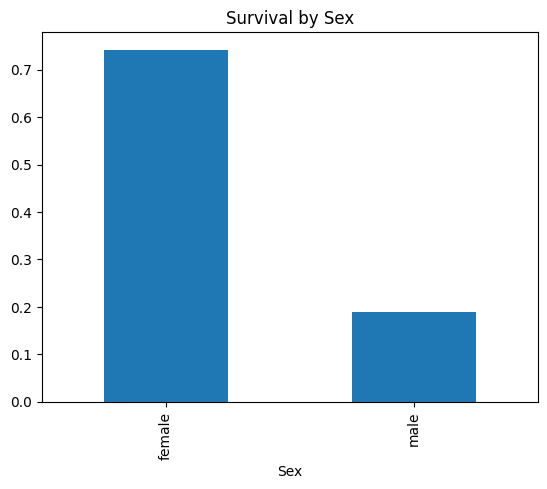

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df.groupby('Sex')['Survived'].mean().plot(
    kind='bar', ax=axes[0], title='Survival Rate by Sex',
    color=['#4C72B0', '#DD8452'], edgecolor='white'
)
axes[0].set_ylabel('Survival Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', ax=axes[1], title='Survival Rate by Passenger Class',
    color=['#55A868', '#C44E52', '#8172B2'], edgecolor='white'
)
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('assets/eda_survival_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering & Preprocessing

**Feature selection rationale:**
- `Cabin` excluded — >77% missing; imputing would add noise, not signal
- `Name`, `Ticket`, `PassengerId` excluded — no predictive signal without further engineering

**Pipeline design:**
- Numeric: median imputation (robust to age outliers) → standard scaling
- Categorical: mode imputation (handles 2 missing `Embarked`) → one-hot encoding
- Stratified split preserves the ~38% survival rate across train and test

In [ ]:
NUMERIC_FEATURES     = ['Age', 'Fare', 'SibSp', 'Parch']
CATEGORICAL_FEATURES = ['Sex', 'Pclass', 'Embarked']

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),  # ignore: handles unseen values at inference
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, NUMERIC_FEATURES),
    ('cat', cat_pipe, CATEGORICAL_FEATURES),
])

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Survival rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}')

## 5. Model Training & Evaluation

Four classifiers are trained end-to-end through the same preprocessing pipeline. Each is evaluated on F1 (hard predictions) and ROC-AUC (ranking quality).

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),  # default 100 doesn't converge here
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),  # capped to prevent overfitting
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),  # odd k avoids tie-breaking
}

results = {}
for name, clf in models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    results[name] = {
        'F1':      round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
    }
    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       110
           1       0.75      0.58      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179


--- SVM ---
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       110
           1       0.82      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted 

## 6. Results

Summary table and bar chart comparing all four models on ROC-AUC.

In [ ]:
results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
print(results_df.to_string())

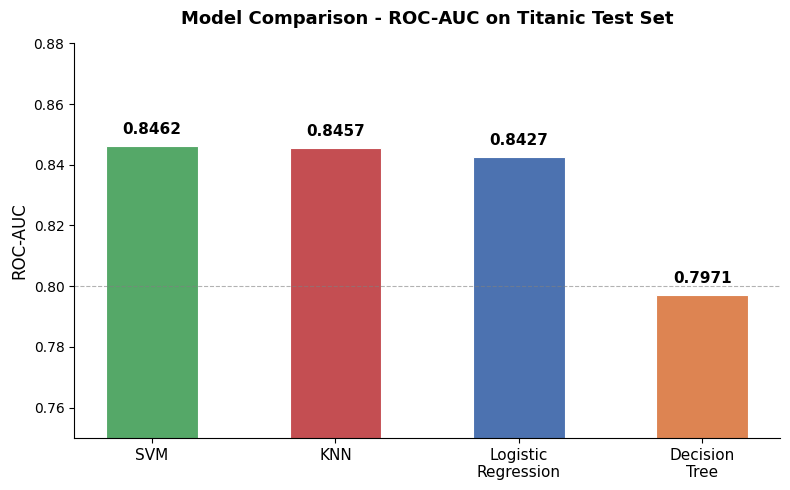

Saved model_comparison.png


In [ ]:
colors = ['#55A868', '#4C72B0', '#C44E52', '#DD8452']
fig, ax = plt.subplots(figsize=(8, 5))

# chr(10) avoids embedding a literal newline in Jupyter JSON source
labels = [m.replace(' ', chr(10)) for m in results_df.index]
bars = ax.bar(labels, results_df['ROC-AUC'], color=colors[:len(results_df)],
              width=0.5, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, results_df['ROC-AUC']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0.75, 0.88)  # zoomed to make inter-model differences visible
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('Model Comparison — ROC-AUC on Test Set', fontsize=13, fontweight='bold', pad=14)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('assets/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusion

| Model | F1 | ROC-AUC |
|---|---|---|
| **SVM** | **0.736** | **0.846** |
| Logistic Regression | 0.724 | 0.843 |
| KNN | 0.709 | 0.846 |
| Decision Tree | 0.656 | 0.797 |

**Key takeaways:**
- SVM (RBF) achieves the best F1 and is tied for best ROC-AUC. Logistic Regression is within 0.003 ROC-AUC with no tuning — a strong choice when interpretability matters.
- Decision Tree underperforms even with depth capping, suggesting the decision boundary benefits from smooth non-linearity.
- Survivor recall (0.58–0.67) lags non-survivor recall (0.88–0.91) across all models, reflecting the 110:69 class imbalance in the test set.

**Potential improvements:**
- Feature engineering: title extraction from `Name`, deck from `Cabin`, `Sex × Pclass` interaction
- Address class imbalance: `class_weight='balanced'` or threshold tuning
- Hyperparameter tuning: `GridSearchCV` / `RandomizedSearchCV` on SVM `C` and `gamma`
- Ensemble methods: Random Forest, Gradient Boosting (XGBoost/LightGBM)